# Customer Value Lifetime Analysis

**Objectives** 

Estimate customer lifetime value for each customer over the next 30 days (following "2011-12-09").

**Key Outputs**

Data containing estimated CLV for customers  stored in `data/analysis/clv.parquet` to be used in customer insights dashboard in  PowerBI. 


**Data**

The data is queries from `data/sqliteDB/sales.db` using the query 'Q_clv' in `scripts/SQL_queries.py`. The variables are defines as follows.
- `CustomerId`: unique Id assigned to each customer. 
- `recency`: number of days between first and last orders (zero for single purchase customers). 
- `frequency`: total number of repeated orders.
- `tenure`: number of days since first order. 
- `monetary_value`: average revenue per order (for each customer, total revenue / total number of orders). 


The query `Q_rfm` contains a subquery called `Qsub_Order_Data` which filters:  
- All orders with `C` in the invoice number. These entries correspond to cancellations in order. 
- Entries with negative or 0 revenue. These entries correspond to errors.
- Orders with CategoryLabel being NULL. In `1_create_categories`, categories corresponding to system logs (broken stock, damages, etc) are given NULL entry. Note here that valid entries with no descriptions are given 'NO DESCRIPTION'. 


In [48]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
from lifetimes import BetaGeoFitter
from lifetimes import GammaGammaFitter

from lifetimes.plotting import plot_frequency_recency_matrix
from lifetimes.plotting import plot_probability_alive_matrix

from lifetimes.plotting import plot_period_transactions

In [49]:
# Query CLV data
sys.path.insert(0, str(Path.cwd().parents[0])) # add project root to sys path
from scripts.SQL_queries import main as query

clv_df = query(clv=True)
clv_df.head()


,CustomerID,recency,frequency,tenure,monetary_value
0,12347.0,365.0,6,367.0,638.152857
1,12348.0,283.0,3,358.0,375.210000
2,12349.0,0.0,0,18.0,1758.070000
3,12350.0,0.0,0,310.0,294.400000
4,12352.0,260.0,6,296.0,187.158571


## Exploratory Data Analysis

We check the distribution of Receny, frequency, Monetary Value and Tenure. 

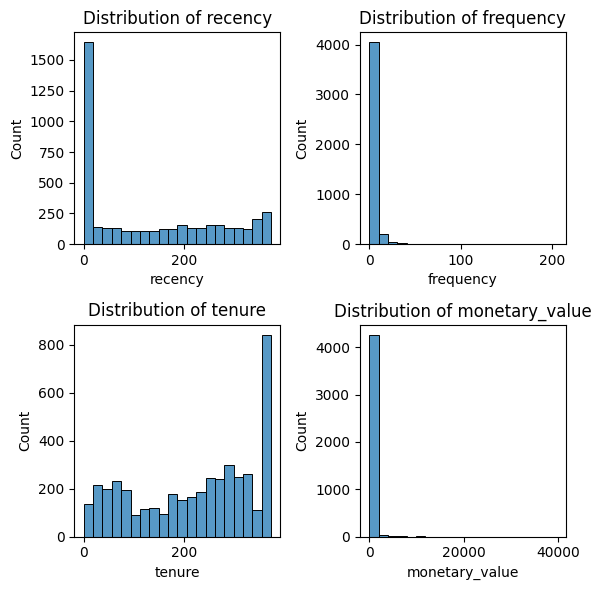

In [50]:
# --- Plot distributions of RFM variables -- #
variable_list = ['recency', 'frequency', 'tenure', 'monetary_value']
fig, ax = plt.subplots(2, 2, figsize=(6,6))

for i, var in enumerate(variable_list):
    # Plot histograms
    sns.histplot(
        data=clv_df,
        x=var,
        bins=20,
        ax=ax[i//2, i%2]
    )
    # Set titles
    ax[i//2, i%2].set_title(f'Distribution of {var}')

# Adjust layout and show plot
plt.tight_layout()
plt.show()
    

Recency, frequency and monetary value are all skewed. 

Checking NAs revels a single entry in customerId. This single entry was generated from aggregating over CustoemrId and can be dropped. 

In [51]:
# Check for NA values
NAs = clv_df.isna().sum()
print(NAs)

CustomerID        0
recency           0
frequency         0
tenure            0
monetary_value    0
dtype: int64


## Model Selection and Assumptions

Our objective is to fit Beta-Geometric (BG) and Negative Binomial Distributions (NBD) models to transactional variables such as frequency and customer churn, as well as Gamma-Gamma distributions to model customer monetary value. This code utilizes the lifetimes package.

In this section, we verify the assumptions required for these models and investigate any shrinking effects that may be present.

As in the RFM analysis, we have wholesalers that need to be filtered out since they are unlikely to follow the same purchase pattern as retail customers. 

We set the time unit to one month, which should provide our model with greater robustness.

In [52]:
# --- Preprocessing --- #

# Remove invalid customer IDs
clv_df.dropna(subset=['CustomerID'], inplace=True)

# Remove single purchase cancelled customers
clv_df = clv_df[clv_df['frequency']>=0]

# Remove wholesalers 
mv_cut = clv_df['monetary_value'].quantile(0.95)
f_cut = clv_df['frequency'].quantile(0.95)

wholesales = (clv_df['monetary_value'] > mv_cut) * (clv_df['frequency'] > f_cut)
clv_df = clv_df[~wholesales]


### BG/NBD Model

For the BG/NBD model, we need:
- frequency >= 0,
- recency >= 0,
- tenure > 0 and
- tenure >= recency.

In [53]:
# --- Check assumptions for BG/NBD model  --- # 

# BetaGeo assumptions 
valid_bgnbd = (
    (clv_df['frequency'] >= 0) &
    (clv_df['recency'] >= 0) &
    (clv_df['tenure'] > 0) &
    (clv_df['recency'] <= clv_df['tenure'])
)

invalid_customers = clv_df[~valid_bgnbd]
print('Number of customers not satisfying BG/NBD assumptions: ' + str(invalid_customers.shape[0]))

# Proportion single purchase customers
one_time_customers = (clv_df['frequency'] == 0)
print('Proportion of single purchase customers: ' + str(one_time_customers.mean()))


Number of customers not satisfying BG/NBD assumptions: 1
Proportion of single purchase customers: 0.34729006745754826


The fitting process using lifetimes will default to population averages for customers that do not meet the above criteria. We nonetheless need to check the proportion to gauge potential shrinkage in the results.

### Gamma-Gamma Model 

For the Gamma-Gamma model, we need:
- uncorrelated monetary-value and frequency
- frequency >= 1 and
- monetary values >0. 
Note that the Gamma-Gamma fitter from lifetimes cannot handle this, so we must exclude these cutomers prior to fitting. 

In [54]:
# --- Check assumptions for Gamma-Gamma model  --- # 

# Check Correlation
coeff = pearsonr(clv_df['frequency'], clv_df['monetary_value'])
print('Correlation coefficient between frequency and monetary value: ' + str(coeff[0]))
print('pvalue: ' + str(coeff[1]))

# Frequency > 0 and Monetary value > 0
valid_gamma = (
    (clv_df['monetary_value']>0) &
    (clv_df['frequency']>=1)
)

# Print invalid rows
print('Rows not satisfying the frequency and monetary value assumptions:')
invalid_customers = clv_df[~valid_gamma]
invalid_customers

Correlation coefficient between frequency and monetary value: 0.01082815445890837
pvalue: 0.477839737143548
Rows not satisfying the frequency and monetary value assumptions:


,CustomerID,recency,frequency,tenure,monetary_value
2,12349.0,0.0,0,18.0,1758.07
3,12350.0,0.0,0,310.0,294.40
5,12353.0,0.0,0,204.0,89.00
6,12354.0,0.0,0,232.0,1208.28
7,12355.0,0.0,0,214.0,484.90
...,...,...,...,...,...
4312,18276.0,0.0,0,43.0,365.84
4313,18277.0,0.0,0,58.0,97.63
4314,18278.0,0.0,0,73.0,201.80
4315,18280.0,0.0,0,277.0,180.60


The correlation between frequency and moentary value is low. 

There is 1505 rows that do no satisfy the moentary value and frequency assumption. We note here that the `customer_lifetime_value` fitter will handle single purchase customers by falling back to population average. 


## Model Fitting and Evaluation

### BG/NBD model

A BG/NBD model is fit ro predict the expected number of purchases for each customer in the next 30 days. 


In [55]:
clv_df

,CustomerID,recency,frequency,tenure,monetary_value
0,12347.0,365.0,6,367.0,638.152857
1,12348.0,283.0,3,358.0,375.210000
2,12349.0,0.0,0,18.0,1758.070000
3,12350.0,0.0,0,310.0,294.400000
4,12352.0,260.0,6,296.0,187.158571
...,...,...,...,...,...
4315,18280.0,0.0,0,277.0,180.600000
4316,18281.0,0.0,0,180.0,113.820000
4317,18282.0,119.0,1,126.0,95.050000
4318,18283.0,334.0,15,337.0,155.677500


In [56]:
# -- Fit BG/NBD Model -- #

bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(clv_df['frequency'], clv_df['recency'], clv_df['tenure'])
print(bgf.summary)


forecast_time = 30 # number of days to forecast into the future

clv_df[str(forecast_time)+'day_expected_purchase'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    forecast_time,
    clv_df['frequency'],
    clv_df['recency'],
    clv_df['tenure']
)

# Probability customer will purchase in the forecasted range
clv_df[str(forecast_time)+'day_prob_purchase'] = (
    1 - np.exp(-clv_df[str(forecast_time)+'day_expected_purchase'])
)

# Predicted number of future purchases
na_count = clv_df[str(forecast_time)+'day_expected_purchase'].isna().mean() 
print("Proposition of NAs from fitting: " + str(na_count))

            coef  se(coef)  lower 95% bound  upper 95% bound
r       0.724542  0.022000         0.681423         0.767662
alpha  53.296266  2.026226        49.324863        57.267670
a       0.006111  0.002380         0.001446         0.010775
b       0.250854  0.073564         0.106670         0.395039
Proposition of NAs from fitting: 0.0


The following color plot shows the the expected number of future purchases for each customer as predicted by the model, on the variables recency and frequency. The maximum recency and frequency to plot is the 95% quantile of each variable.

<Axes: title={'center': 'Expected Number of Future Purchases for 30 Units of Time,\nby Frequency and Recency of a Customer'}, xlabel="Customer's Historical Frequency", ylabel="Customer's Recency">

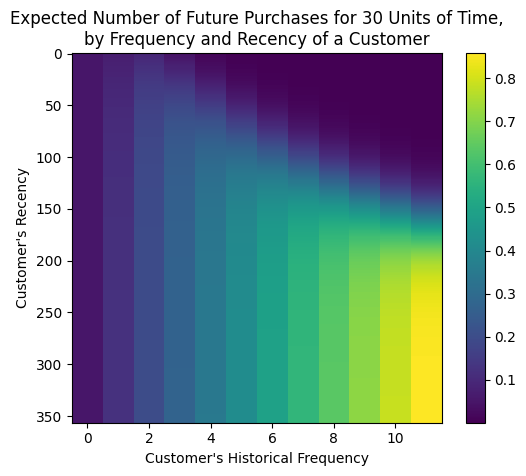

In [57]:
# Expected Future Purchases
plot_frequency_recency_matrix(
    model=bgf, 
    T=forecast_time,
    max_frequency=int(clv_df['frequency'].quantile(0.95)),
    max_recency=int(clv_df['recency'].quantile(0.95))
    )

From the above plot, we observe:
- A tail like top left portion of the colourmap corresponding to 0.4 expected purchases in the next month. 
- Customers with high purchase frequency and 150+ recency have the highest expected purchases in the next month. 
Both groups of customers would be ideal targets for marketing campaigns to increase purchase chance. 


Next we look at te probability of customer being active as a color map against the frequency and recency variables. 

<Axes: title={'center': 'Probability Customer is Alive,\nby Frequency and Recency of a Customer'}, xlabel="Customer's Historical Frequency", ylabel="Customer's Recency">

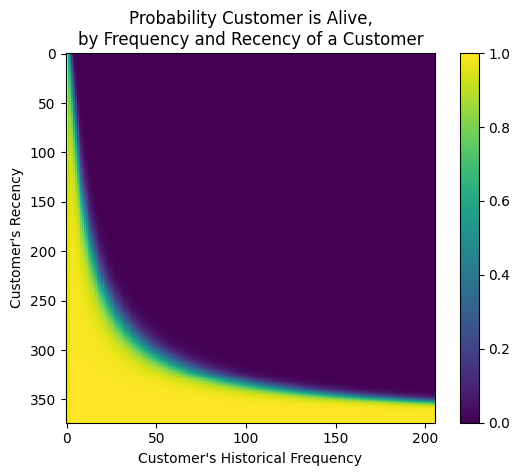

In [58]:
# Probability of Customer Being Alive
plot_probability_alive_matrix(bgf)

Standard probability range of customers activity across frequency and recency. Marketing campaign would be most effective targetting the curve formed by custimers with 0.6 active probability. 

Finally, the following plot shows the number of transactions per customer over callibration time period. 

<Axes: title={'center': 'Frequency of Repeat Transactions'}, xlabel='Number of Calibration Period Transactions', ylabel='Customers'>

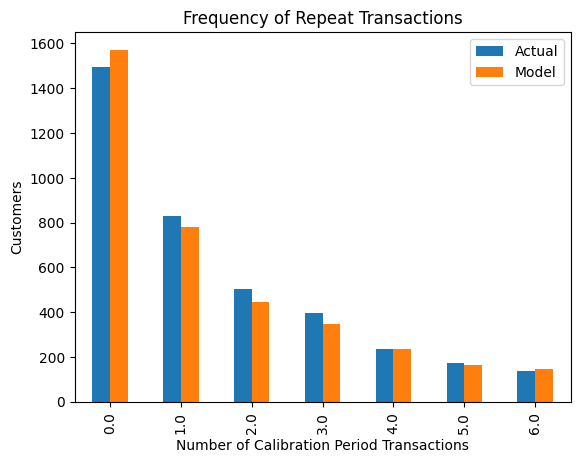

In [59]:
plot_period_transactions(bgf)

We see that the model has fitted the data reasonably well. However, the model should be properly tested on unseen data to properly evaulate its performance. 

### Gamma-Gamma Model

We fit a Gamma-Gamma model to predict the average monetary value of customer purchases.

In [60]:
# --- Fit Gamma Gamma Model --- #

# Keep customers with sufficient data 
mask = (clv_df['monetary_value']>0)*(clv_df['frequency']>1)
gg_data = clv_df[mask]

# Fit model 
ggf = GammaGammaFitter(penalizer_coef=0.1)
ggf.fit(gg_data['frequency'], gg_data['monetary_value'])

print(ggf.summary)

       coef  se(coef)  lower 95% bound  upper 95% bound
p  0.982123  0.036105         0.911357         1.052889
q  0.174566  0.004230         0.166276         0.182856
v  0.924679  0.037111         0.851942         0.997417


## Predict Customer Lifetime Value

In [61]:
# --- Predict CLV --- #

# Calculating the CLV
clv_df['predicted_clv'] = ggf.customer_lifetime_value(
    transaction_prediction_model=bgf, 
    frequency=clv_df['frequency'],
    recency=clv_df['recency'],
    T=clv_df['tenure'],
    monetary_value=clv_df['monetary_value'],
    discount_rate=0.001,
    freq='D'
)



/Users/hoseawondo/NextCloud/Projects/PortfolioProjects/Sales/.venv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Proportion of NAs from fitting: 0.2903000697836706
Proportion of unfitted customers with zero frequency or monetary value: 1.0
Number of customers with negative predicted CLV: 245


Text(0, 0.5, 'count')

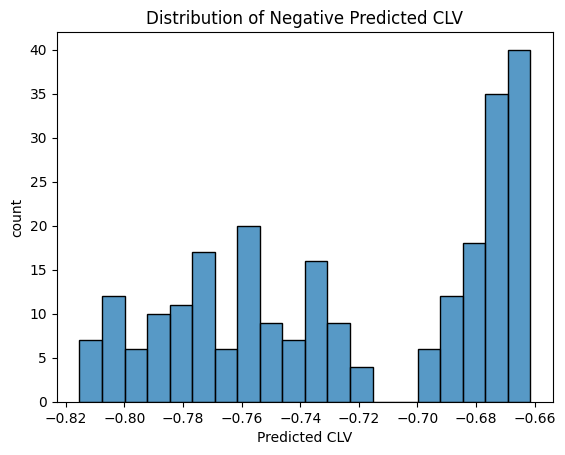

In [62]:
import numpy as np


# Check for NAs in predicted CLV
na_count = clv_df['predicted_clv'].isna().mean() 
print("Proportion of NAs from fitting: " + str(na_count))

# Check if NAs are from customers with zero frequency or monetary value
nan_customers = clv_df[clv_df.isna().any(axis=1)]
prop = np.mean(nan_customers['frequency']*nan_customers['monetary_value'] == 0)
print("Proportion of unfitted customers with zero frequency or monetary value: " + str(prop))

# Check negative CLV values
negative_clv = clv_df[clv_df['predicted_clv'] < 0]
print("Number of customers with negative predicted CLV: " + str(negative_clv.shape[0]))

# Check distribution of predicted CLV with negative values
sns.histplot(negative_clv['predicted_clv'], bins=20)
plt.title('Distribution of Negative Predicted CLV')
plt.xlabel('Predicted CLV')
plt.ylabel('count')

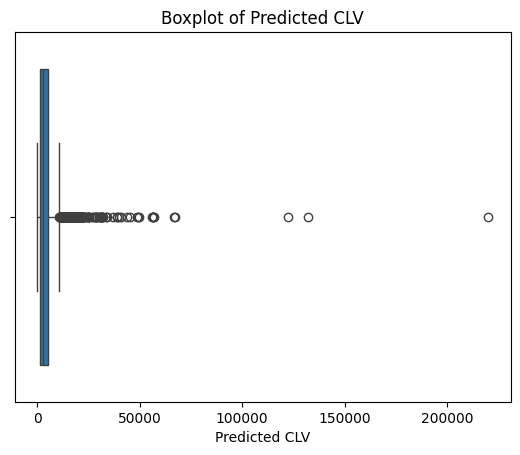

In [63]:
# Check for outliers in predicted CLV
sns.boxplot(x=clv_df['predicted_clv'])
plt.title('Boxplot of Predicted CLV')
plt.xlabel('Predicted CLV')
plt.show()

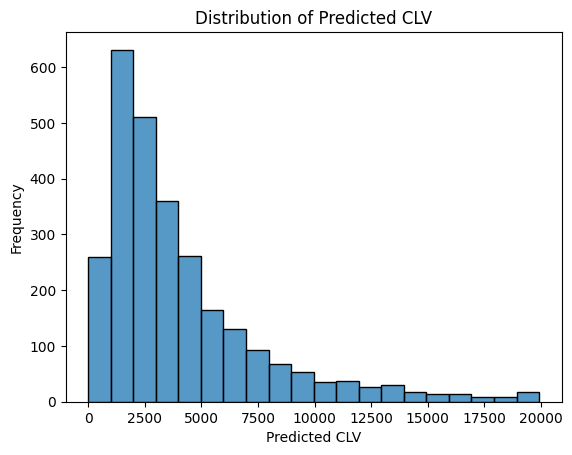

In [64]:

# Check distribution of predicted CLV
mask = (clv_df['predicted_clv'] <= 20000) & (clv_df['predicted_clv'] >= 0)
 
sns.histplot(clv_df[mask]['predicted_clv'], bins=20)
plt.title('Distribution of Predicted CLV')
plt.xlabel('Predicted CLV')
plt.ylabel('Frequency')
plt.show()

In [65]:
# Clip negative CLV values to 0
clv_df['predicted_clv'] = clv_df['predicted_clv'].clip(lower=0)

# Save results to parquet file
OUT_DIR = '../data/analysis'
clv_df.to_parquet(OUT_DIR + "/clv.parquet", index=False)

In [66]:
clv_df

,CustomerID,recency,frequency,tenure,monetary_value,30day_expected_purchase,30day_prob_purchase,predicted_clv
0,12347.0,365.0,6,367.0,638.152857,0.479284,0.380774,4232.189811
1,12348.0,283.0,3,358.0,375.210000,0.270032,0.236645,1675.155396
2,12349.0,0.0,0,18.0,1758.070000,0.302841,0.261284,NaN
3,12350.0,0.0,0,310.0,294.400000,0.059735,0.057986,0.000000
4,12352.0,260.0,6,296.0,187.158571,0.575977,0.437844,1492.007614
...,...,...,...,...,...,...,...,...
4315,18280.0,0.0,0,277.0,180.600000,0.065693,0.063582,NaN
4316,18281.0,0.0,0,180.0,113.820000,0.092945,0.088757,NaN
4317,18282.0,119.0,1,126.0,95.050000,0.280929,0.244918,2002.841296
4318,18283.0,334.0,15,337.0,155.677500,1.207775,0.701138,2370.631027
